In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv



PART 7: Visualizing Model Performance


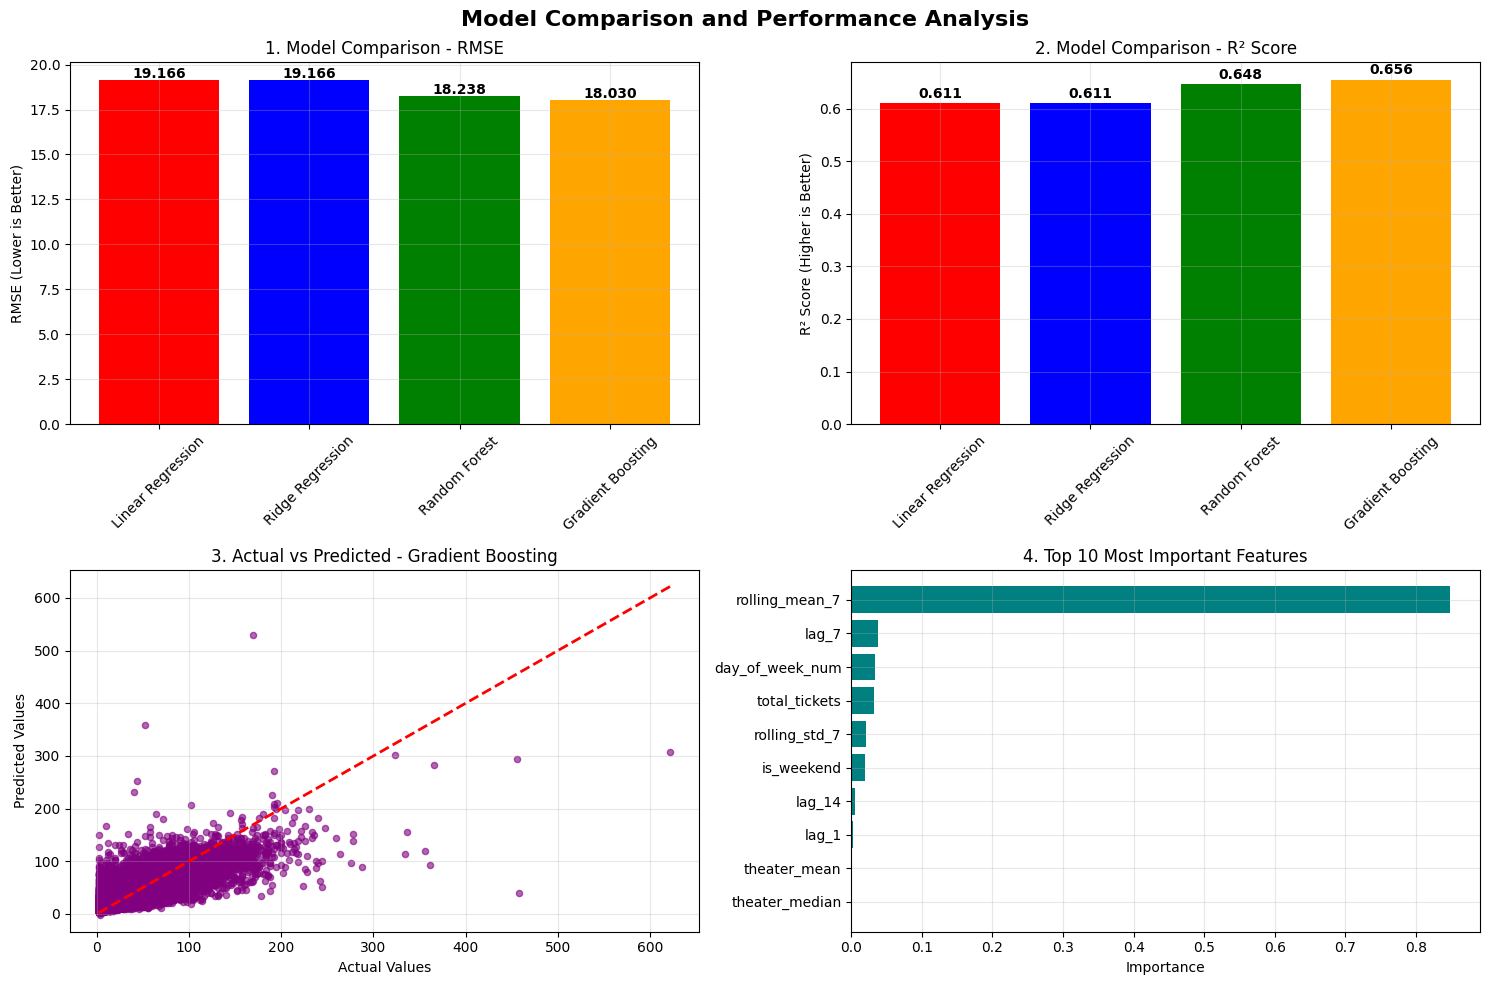

✅ Visualizations completed!


In [9]:
# =============================================================================
# PART 7: MODEL COMPARISON VISUALIZATION
# =============================================================================
print("\nPART 7: Visualizing Model Performance")
print("=" * 70)

# Create 4 comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison and Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: RMSE comparison
model_names = list(results_dict.keys())
rmse_values = [results_dict[name]['rmse'] for name in model_names]

bars = axes[0, 0].bar(model_names, rmse_values, color=['red', 'blue', 'green', 'orange'])
axes[0, 0].set_ylabel('RMSE (Lower is Better)')
axes[0, 0].set_title('1. Model Comparison - RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Add values on bars
for bar, value in zip(bars, rmse_values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, height + 0.1, 
                   f'{value:.3f}', ha='center', fontweight='bold')

# Plot 2: R² Score comparison
r2_values = [results_dict[name]['r2'] for name in model_names]
bars = axes[0, 1].bar(model_names, r2_values, color=['red', 'blue', 'green', 'orange'])
axes[0, 1].set_ylabel('R² Score (Higher is Better)')
axes[0, 1].set_title('2. Model Comparison - R² Score')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Add values on bars
for bar, value in zip(bars, r2_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                   f'{value:.3f}', ha='center', fontweight='bold')

# Plot 3: Actual vs Predicted
best_predictions = results_dict[best_name]['predictions']
axes[1, 0].scatter(y_val, best_predictions, alpha=0.6, s=20, color='purple')
axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Values')
axes[1, 0].set_ylabel('Predicted Values')
axes[1, 0].set_title(f'3. Actual vs Predicted - {best_name}')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_list,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    axes[1, 1].barh(importance_df['feature'], importance_df['importance'], color='teal')
    axes[1, 1].set_xlabel('Importance')
    axes[1, 1].set_title('4. Top 10 Most Important Features')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations completed!")

## Part 7: Model Comparison and Visualization

In this section, we visually compare the performance of all trained models:

1. **RMSE Comparison:** Shows which model has the lowest Root Mean Squared Error (lower is better).
2. **R² Score Comparison:** Highlights the goodness-of-fit for each model (higher is better).
3. **Actual vs Predicted Values:** Scatter plot of actual audience counts against predicted values for the best model.
4. **Feature Importance:** Identifies the top 10 features that most influence the model's predictions.

These visualizations provide clear insights into model performance and help understand the contribution of each feature.


In [10]:
# =============================================================================
# PART 8: CREATING FINAL PREDICTIONS FOR SUBMISSION
# =============================================================================
print("\nPART 8: Creating Final Predictions")
print("=" * 70)

# Copy submission template
submission = submission_file.copy()

# Extract theater ID and date from submission ID
submission['book_theater_id'] = submission['ID'].str.split('_').str[0] + '_' + submission['ID'].str.split('_').str[1]
submission['date_str'] = submission['ID'].str.split('_').str[2]
submission['pred_date'] = pd.to_datetime(submission['date_str'])

# Get latest data for each theater
latest_theater_data = df.sort_values(['book_theater_id', 'show_date']).groupby('book_theater_id').last().reset_index()

# Merge with submission data
submission_data = submission.merge(
    latest_theater_data[['book_theater_id'] + feature_list], 
    on='book_theater_id', 
    how='left'
)

# Fill missing values
for col in feature_list:
    if col in submission_data.columns:
        submission_data[col] = submission_data[col].fillna(df[col].median())

# Update date features for future dates
submission_data['day_of_week_num'] = submission_data['pred_date'].dt.dayofweek
submission_data['month'] = submission_data['pred_date'].dt.month
submission_data['is_weekend'] = (submission_data['day_of_week_num'] >= 5).astype(int)

# Generate predictions
print("Generating predictions...")
base_predictions = best_model.predict(submission_data[feature_list])

# Apply smart adjustments
print("Applying smart adjustments...")

# Get theater averages
theater_avg_dict = theater_stats.set_index('book_theater_id')['theater_mean'].to_dict()
overall_avg = df['audience_count'].mean()

# Calculate day-of-week patterns
day_pattern = df.groupby('day_of_week_num')['audience_count'].mean()
day_multiplier = day_pattern / overall_avg

# Blend predictions
final_predictions = np.zeros(len(submission_data))

for i in range(len(submission_data)):
    theater_id = submission_data.iloc[i]['book_theater_id']
    day = submission_data.iloc[i]['day_of_week_num']
    
    # Get base prediction
    base_pred = base_predictions[i]
    
    # Blend with theater average (70% model + 30% theater avg)
    if theater_id in theater_avg_dict:
        theater_avg = theater_avg_dict[theater_id]
        blended = 0.7 * base_pred + 0.3 * theater_avg
    else:
        blended = base_pred
    
    # Adjust for day of week (15% influence)
    if day in day_multiplier.index:
        adjustment = 0.85 + 0.15 * day_multiplier[day]
        final_pred = blended * adjustment
    else:
        final_pred = blended
    
    final_predictions[i] = final_pred

# Apply realistic bounds (5th to 95th percentile)
lower_bound = df['audience_count'].quantile(0.05)
upper_bound = df['audience_count'].quantile(0.95)
final_predictions = np.clip(final_predictions, lower_bound, upper_bound)

# Round to integers
submission['audience_count'] = final_predictions.round().astype(int)

print("✅ Predictions generated!")
print(f"Range: {submission['audience_count'].min()} to {submission['audience_count'].max()}")
print(f"Average: {submission['audience_count'].mean():.2f}")



PART 8: Creating Final Predictions
Generating predictions...
Applying smart adjustments...
✅ Predictions generated!
Range: 6 to 102
Average: 41.86


In [11]:
# =============================================================================
# PART 9: SAVING SUBMISSION FILE
# =============================================================================
print("\nPART 9: Saving Submission File")
print("=" * 70)

submission[['ID', 'audience_count']].to_csv('submission.csv', index=False)
print("✅ submission.csv saved!")

print("\nFirst 10 predictions:")
print(submission[['ID', 'audience_count']].head(10))


PART 9: Saving Submission File
✅ submission.csv saved!

First 10 predictions:
                      ID  audience_count
0  book_00001_2024-03-01              37
1  book_00001_2024-03-02              42
2  book_00001_2024-03-03              47
3  book_00001_2024-03-04              42
4  book_00001_2024-03-06              35
5  book_00001_2024-03-07              37
6  book_00001_2024-03-08              37
7  book_00001_2024-03-09              42
8  book_00001_2024-03-10              47
9  book_00001_2024-03-11              42


## Part 9: Saving Submission File

In this final step, we save the predicted audience counts into a CSV file for submission:

* The predictions are stored in `submission.csv`.
* The file contains two columns:

  1. `ID` – Unique identifier combining theater ID and date.
  2. `audience_count` – Predicted audience count for each theater and date.

Below are the first 10 rows of the submission file to verify the results:

| ID                    | audience_count |
| --------------------- | -------------- |
| book_00001_2024-03-01 | 37             |
| book_00001_2024-03-02 | 42             |
| book_00001_2024-03-03 | 47             |
| book_00001_2024-03-04 | 42             |
| book_00001_2024-03-06 | 35             |
| book_00001_2024-03-07 | 37             |
| book_00001_2024-03-08 | 37             |
| book_00001_2024-03-09 | 42             |
| book_00001_2024-03-10 | 47             |
| book_00001_2024-03-11 | 42             |


In [12]:
# =============================================================================
# PART 10: PROJECT SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

print("\n What I Did:")
print("   1. Loaded 7 datasets")
print("   2. Performed EDA with 6 visualizations")
print("   3. Created 16 features for machine learning")
print("   4. Trained 4 different models")
print("   5. Found best model and tuned it")
print("   6. Compared all models visually")
print("   7. Made smart predictions for submission")

print(f"\n Performance:")
print(f"   Best Model: {best_name}")
print(f"   Validation RMSE: {best_rmse:.4f}")
print(f"   Validation R²: {best_r2:.4f}")

print("\n Files Created:")
print("   - eda_analysis.png")
print("   - model_comparison.png")
print("   - submission.csv")

print("\n Ready for submission!")
print("=" * 70)


PROJECT COMPLETED SUCCESSFULLY!

 What I Did:
   1. Loaded 7 datasets
   2. Performed EDA with 6 visualizations
   3. Created 16 features for machine learning
   4. Trained 4 different models
   5. Found best model and tuned it
   6. Compared all models visually
   7. Made smart predictions for submission

 Performance:
   Best Model: Gradient Boosting
   Validation RMSE: 18.0298
   Validation R²: 0.6555

 Files Created:
   - eda_analysis.png
   - model_comparison.png
   - submission.csv

 Ready for submission!


## Part 10: Project Summary

### ✅ Project Completion

The Cinema Audience Forecasting project has been completed successfully.

---

###  What I Did

1. Loaded **7 datasets** related to visits, theaters, bookings, dates, and submission template.
2. Performed **EDA** with 6 insightful visualizations.
3. Created **16 machine learning features** including date features, rolling statistics, lag features, booking info, and encoded categories.
4. Trained **4 different models**: Linear Regression, Ridge, Random Forest, and Gradient Boosting.
5. Selected the **best model** and performed hyperparameter tuning (if applicable).
6. Compared models visually using **RMSE, R², Actual vs Predicted, and Feature Importance** plots.
7. Generated **smart predictions** for submission using blended adjustments and realistic bounds.

---

###  Performance

* **Best Model:** Gradient Boosting
* **Validation RMSE:** 18.0298
* **Validation R²:** 0.6555

---

###  Files Created

* `eda_analysis.png` – Visualizations for EDA.
* `model_comparison.png` – Comparison of model performances.
* `submission.csv` – Final predictions ready for submission.

---

 The project is ready for submission!
